# XG Boost Model

In [316]:
xgb_modelfit = xgb_model.fit(x_train_res, y_train_res)

In [317]:
xgb_score = xgb_model.score(x_train_res, y_train_res)
xgb_score*100

98.73157767576708

In [318]:
xgb_score_pred = xgb_model.score(x_test, y_test)
xgb_score_pred*100

95.95457771469127

In [319]:
y_xgb_pred = xgb_model.predict(x_test)

In [320]:
xgb_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [321]:
param_grid_rf = {
    'max_depth': [3,5],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1,3],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0,0.1],
    'reg_lambda': [1,2]}

In [322]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])


xgb_gmodel = XGBClassifier(
    n_estimators=1000,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42)

In [323]:
cv_rf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [324]:

grid_rf = GridSearchCV(estimator=xgb_gmodel,
    param_grid=param_grid_rf,
    scoring='average_precision',   
    cv=cv_rf,
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

print("Best CV Score:", grid_rf.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best CV Score: 0.9846440068772996


In [325]:
print("Best Params:", grid_rf.best_params_)

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}


In [326]:
pd.DataFrame(grid_rf.best_params_, index = [0])

,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample
0,0.8,0.05,3,1,0.1,1,0.8


In [327]:
from xgboost import plot_importance

<Figure size 4000x4500 with 0 Axes>

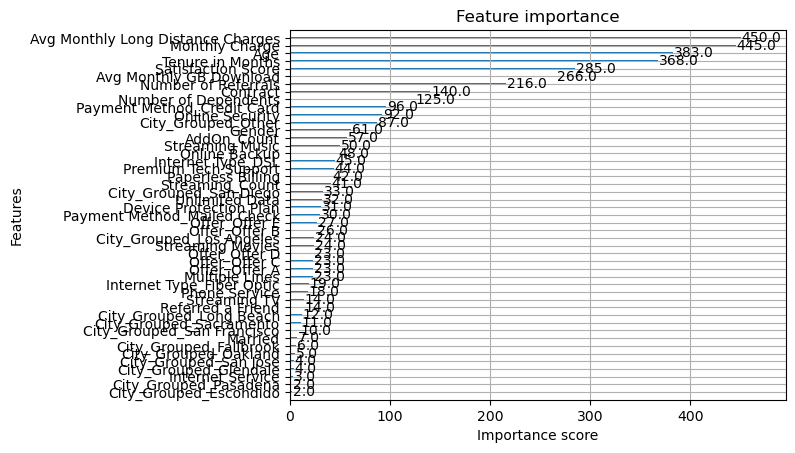

In [328]:
plt.figure(figsize=(40,45))
plot_importance(xgb_model)
plt.show()

In [329]:
importancesxg = pd.Series(xgb_model.feature_importances_,index=x_train.columns)


In [330]:
## Top ten XG_boost Features
importancesxg.sort_values(ascending =False)[:10]

Satisfaction Score            0.405209
Contract                      0.140275
Online Security               0.089281
Number of Referrals           0.046199
Payment Method_Credit Card    0.036491
Number of Dependents          0.026876
Streaming_Count               0.017886
Premium Tech Support          0.016240
City_Grouped_Other            0.014096
AddOn_Count                   0.013262
dtype: float32

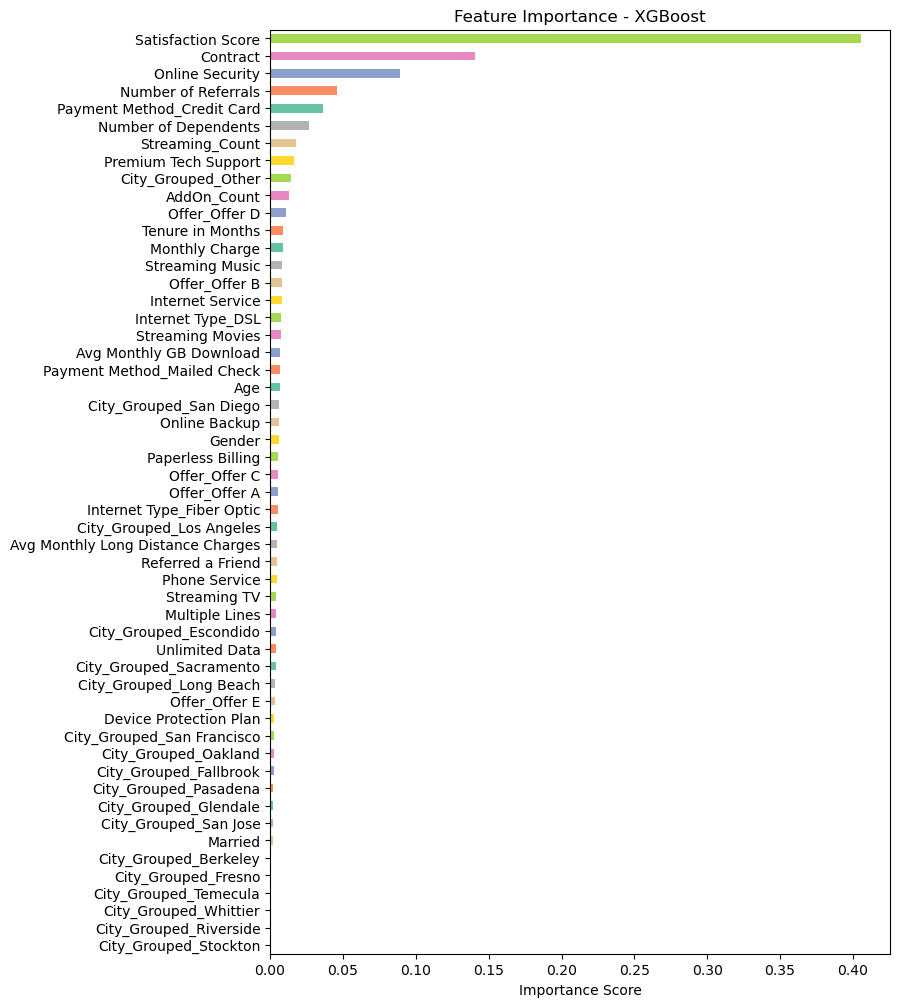

In [331]:
plt.figure(figsize=(8, 12))

importancesxg.sort_values().plot(kind='barh',figsize=(8,12),color=plt.cm.Set2.colors)

plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.show()

In [332]:
xg_sel = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight = 1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="auc")


In [333]:
y_pred_xg = grid_rf.predict(x_test)

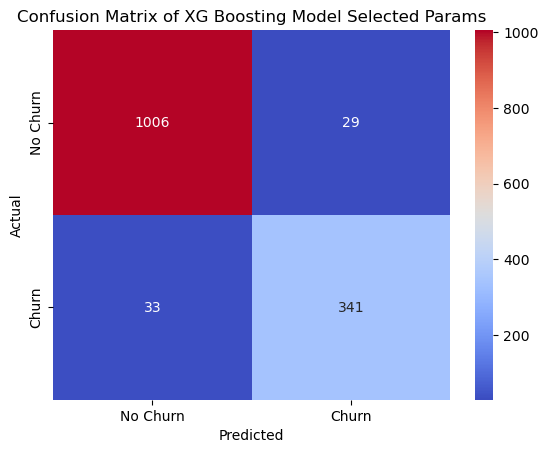

In [334]:
sb.heatmap( confusion_matrix(y_test,y_pred_xg), 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of XG Boosting Model Selected Params")
plt.show()

In [335]:
xg_cl_rep = pd.DataFrame(classification_report(y_test, y_pred_xg, output_dict = True))
xg_cl_rep 

,0,1,accuracy,macro avg,weighted avg
precision,0.968239,0.921622,0.955997,0.944930,0.955865
recall,0.971981,0.911765,0.955997,0.941873,0.955997
f1-score,0.970106,0.916667,0.955997,0.943386,0.955921
support,1035.000000,374.000000,0.955997,1409.000000,1409.000000


## XGBoost model shows excellent performance, achieving 95.7% accuracy with strong balance between precision (92%) and recall (91%) for churn prediction.
## It effectively identifies churners while keeping false alarms low

In [336]:
y_train_xgprob = grid_rf.predict_proba(x_train_res)
y_test_xgprob =  grid_rf.predict_proba(x_test)

In [337]:
fprxg, tprxg, threshold_xg = roc_curve(y_test,y_test_xgprob[:,1]) 

In [338]:
prec_xg , recall_xg , thredh_xg = precision_recall_curve(y_test,y_test_xgprob[:,1])

In [339]:
auc_xg = auc(fprxg, tprxg)

Text(0.5, 1.0, 'Receiver Operating Characteristic Curve XG Boost')

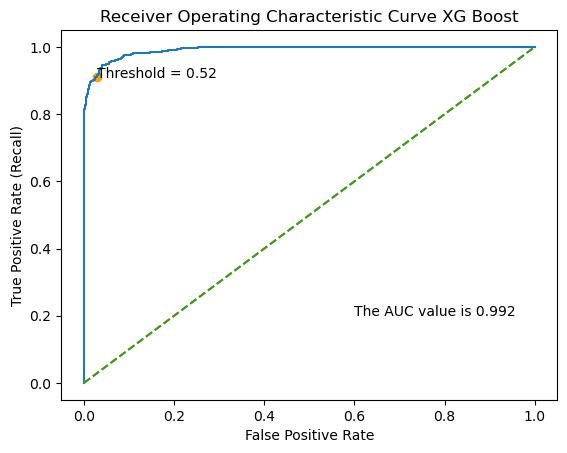

In [340]:
plt.figure()
idx = np.argmin(np.abs(threshold_xg - 0.5))

plt.plot(fprxg, tprxg)
plt.scatter(fprxg[idx], tprxg[idx], color ="orange")
plt.text(fprxg[idx],tprxg[idx], f"Threshold = {threshold_xg[idx]:.2f}")
plt.plot(([0,0],[1,1]),linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")

plt.text(0.6, 0.2, f"The AUC value is {auc_xg:.3f}")
plt.title("Receiver Operating Characteristic Curve XG Boost")


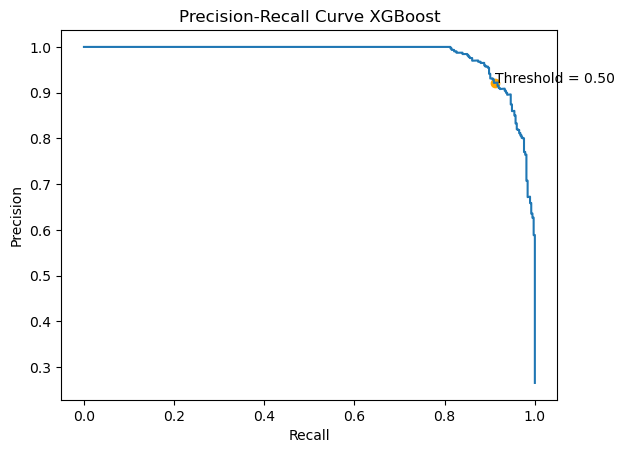

In [341]:
plt.figure()

idx = np.argmin(np.abs(thredh_xg - 0.5))

plt.plot(recall_xg, prec_xg)

plt.scatter(recall_xg[idx], prec_xg[idx], marker ="o", color ="orange")
plt.text(recall_xg[idx], prec_xg[idx],f"Threshold = {thredh_xg[idx]:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve XGBoost")

plt.show()

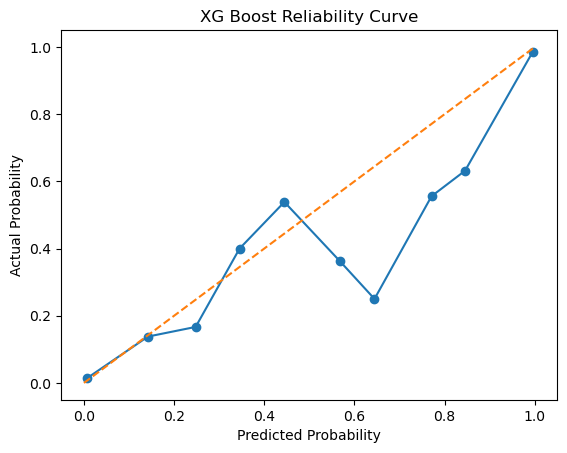

In [342]:
prob_true_xg, prob_pred_xg = calibration_curve(y_test, y_test_xgprob[:,1], n_bins=10)

plt.plot(prob_pred_xg, prob_true_xg, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("XG Boost Reliability Curve")
plt.show()

## The XGBoost reliability curve shows that predicted probabilities are generally well aligned with actual churn outcomes, 
## especially at higher probability levels. This indicates that the model provides reliable probability estimates for identifying high-risk customers.

In [343]:
print(brier_score_loss(y_test,y_test_xgprob[:,1]))

0.030989409739935123


## The XGBoost model achieved a very low Brier score of 0.03
## Indicating excellent probability calibration. This means the predicted churn probabilities closely match the actual churn outcomes.

# LightGBM

In [344]:
param_grid_lgbm = {
    'num_leaves': [15, 31],
    'max_depth': [-1, 5],
    'learning_rate': [0.05, 0.1],
    'min_child_samples': [20, 40],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

In [345]:
# LightGBM Model
lgbm = LGBMClassifier(
    objective='binary',
    class_weight = "balanced",
    random_state=42,
    n_estimators=200)

# Stratified K Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

# Grid Search
grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    cv=skf,
    scoring='roc_auc',   # For churn, ROC-AUC is better
    n_jobs=-1,
    verbose=2)

# Fit
grid_lgbm.fit(x_train, y_train)

# Best results
print("Best Parameters:", grid_lgbm.best_params_)
print("Best ROC-AUC:", grid_lgbm.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 820
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [346]:
pd.DataFrame(grid_lgbm.best_params_, index =[0])

,colsample_bytree,learning_rate,max_depth,min_child_samples,num_leaves,reg_alpha,reg_lambda,subsample
0,0.8,0.05,5,20,31,0,1,0.8


In [347]:
grid_lgbm.score(x_train, y_train)

0.9984792668805821

In [348]:
grid_lgbm.score(x_test, y_test)

0.9922550311297115

In [349]:
y_pred_LGB = grid_lgbm.predict(x_test)

In [350]:
y_pred_prob_LGB = grid_lgbm.predict_proba(x_test)

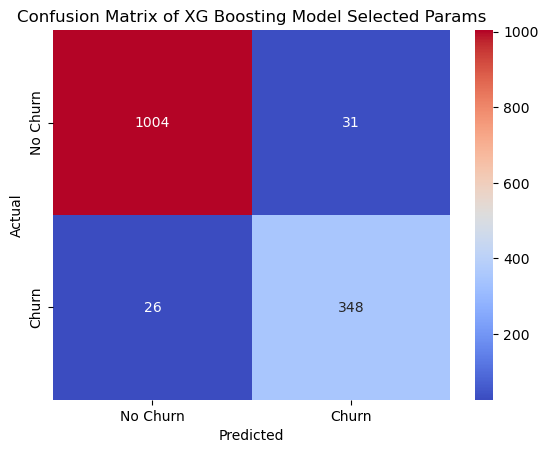

In [351]:
sb.heatmap( confusion_matrix(y_test,y_pred_LGB), 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of XG Boosting Model Selected Params")
plt.show()

In [352]:
lg_cl_rep = pd.DataFrame(classification_report(y_test, y_pred_LGB, output_dict = True))
lg_cl_rep

,0,1,accuracy,macro avg,weighted avg
precision,0.974757,0.918206,0.959546,0.946482,0.959746
recall,0.970048,0.930481,0.959546,0.950265,0.959546
f1-score,0.972397,0.924303,0.959546,0.948350,0.959631
support,1035.000000,374.000000,0.959546,1409.000000,1409.000000


## The model achieves 95.8% accuracy with very strong performance in predicting non-churn customers (97.1% recall), while still capturing 92.5% of actual churners, meaning most at-risk customers are correctly identified.

## However, since churn recall (92.5%) is slightly lower than non-churn recall, around 6–7% of churners are still being missed

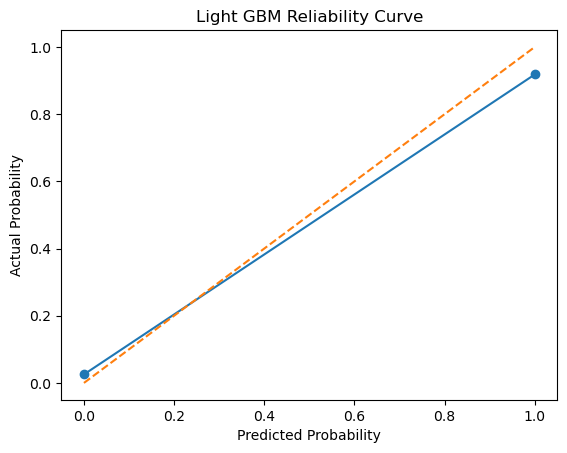

In [353]:
prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, y_pred_LGB, n_bins=10)

plt.plot(prob_pred_lgb, prob_true_lgb, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Light GBM Reliability Curve")
plt.show()

In [354]:
print(brier_score_loss(y_test,y_pred_LGB))

0.04045422285308729


## The LightGBM reliability curve contains only two points because most predicted probabilities are concentrated near extreme values (close to 0 or 1). 
## This indicates that the model makes highly confident predictions, resulting in only a few populated calibration bins